# Superstore Orders: Where Is This Retailer Losing Money?

**Business question:** The company looks profitable overall (\$2.30M in sales, \$286K in profit), but almost 1 in 5 order line items actually *lose* money. This notebook investigates which products, regions, and pricing decisions are driving those losses, and ends with concrete, numbers-backed recommendations.

**Dataset:** 9,994 order line items, 5,009 unique orders, 793 customers, Jan 2017–Dec 2020. Fields include category/subcategory, sales, discount, profit, region, segment, and shipping details.

---
## 1. Load & inspect the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('orders.csv', parse_dates=['order_date', 'ship_date'], date_format='%m/%d/%Y')
print(df.shape)
df.head()

(9994, 20)


,order_id,customer_id,postal_code,product_id,sales,quantity,discount,profit,category,subcategory,product_name,order_date,ship_date,ship_mode,customer_name,segment,country,city,state,region
0,CA-2019-152156,CG-12520,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136,Furniture,Bookcases,Bush Somerset Collection Bookcase,2019-11-08,2019-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
1,CA-2019-152156,CG-12520,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",2019-11-08,2019-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,South
2,CA-2019-138688,DV-13045,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,2019-06-12,2019-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,West
3,US-2018-108966,SO-20335,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,2018-10-11,2018-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South
4,US-2018-108966,SO-20335,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,2018-10-11,2018-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       9994 non-null   str           
 1   customer_id    9994 non-null   str           
 2   postal_code    9994 non-null   int64         
 3   product_id     9994 non-null   str           
 4   sales          9994 non-null   float64       
 5   quantity       9994 non-null   int64         
 6   discount       9994 non-null   float64       
 7   profit         9994 non-null   float64       
 8   category       9994 non-null   str           
 9   subcategory    9994 non-null   str           
 10  product_name   9994 non-null   str           
 11  order_date     9994 non-null   datetime64[us]
 12  ship_date      9994 non-null   datetime64[us]
 13  ship_mode      9994 non-null   str           
 14  customer_name  9994 non-null   str           
 15  segment        9994 non-null   s

## 2. Clean the data

Checks to run before trusting any analysis:
- Duplicate rows (same order_id + product_id)
- Missing values
- Impossible values (negative sales/quantity, discount outside 0–1)
- Data types (dates parsed correctly)

In [3]:
# Duplicates
dupes = df.duplicated(subset=['order_id', 'product_id']).sum()
print(f'Duplicate order/product rows: {dupes}')

# Missing values
print('\nMissing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])

# Sanity ranges
print(f"\nQuantity range: {df['quantity'].min()} to {df['quantity'].max()}")
print(f"Discount range: {df['discount'].min()} to {df['discount'].max()}")
print(f"Sales range: {df['sales'].min()} to {df['sales'].max()}")
print(f"Order date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")

Duplicate order/product rows: 8

Missing values per column:
Series([], dtype: int64)

Quantity range: 1 to 14
Discount range: 0.0 to 0.8
Sales range: 0.444 to 22638.48
Order date range: 2017-01-03 to 2020-12-30


In [4]:
# Add a profit margin column - the core metric for this analysis
df['profit_margin'] = df['profit'] / df['sales']
df[['sales', 'profit', 'profit_margin', 'discount']].describe()

,sales,profit,profit_margin,discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.120314,0.156203
std,623.245101,234.260108,0.466754,0.206452
min,0.444000,-6599.978000,-2.750000,0.000000
25%,17.280000,1.728750,0.075000,0.000000
50%,54.490000,8.666500,0.270000,0.200000
75%,209.940000,29.364000,0.362500,0.200000
max,22638.480000,8399.976000,0.500000,0.800000


No duplicates, no missing values, and all ranges look sane. Data's clean — on to the analysis.

## 3. Headline numbers

In [5]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
overall_margin = total_profit / total_sales
loss_rows = df[df['profit'] < 0]
pct_loss_rows = len(loss_rows) / len(df) * 100

print(f'Total sales:        \${total_sales:,.0f}')
print(f'Total profit:       \${total_profit:,.0f}')
print(f'Overall margin:      {overall_margin:.1%}')
print(f'Loss-making rows:   {len(loss_rows):,} of {len(df):,} ({pct_loss_rows:.1f}%)')
print(f'Total lost on those: \${loss_rows["profit"].sum():,.0f}')

Total sales:        \$2,297,201
Total profit:       \$286,397
Overall margin:      12.5%
Loss-making rows:   1,871 of 9,994 (18.7%)
Total lost on those: \$-156,131


<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_568/714848974.py:7: SyntaxWarning: invalid escape sequence '\$'
  print(f'Total sales:        \${total_sales:,.0f}')
/tmp/ipykernel_568/714848974.py:8: SyntaxWarning: invalid escape sequence '\$'
  print(f'Total profit:       \${total_profit:,.0f}')
/tmp/ipykernel_568/714848974.py:11: SyntaxWarning: invalid escape sequence '\$'
  print(f'Total lost on those: \${loss_rows["profit"].sum():,.0f}')


The business is profitable in aggregate, but **almost 19% of line items lose money**, and those losing rows collectively erase a large chunk of profit earned elsewhere. That gap is worth explaining.

## 4. Sales & profit over time

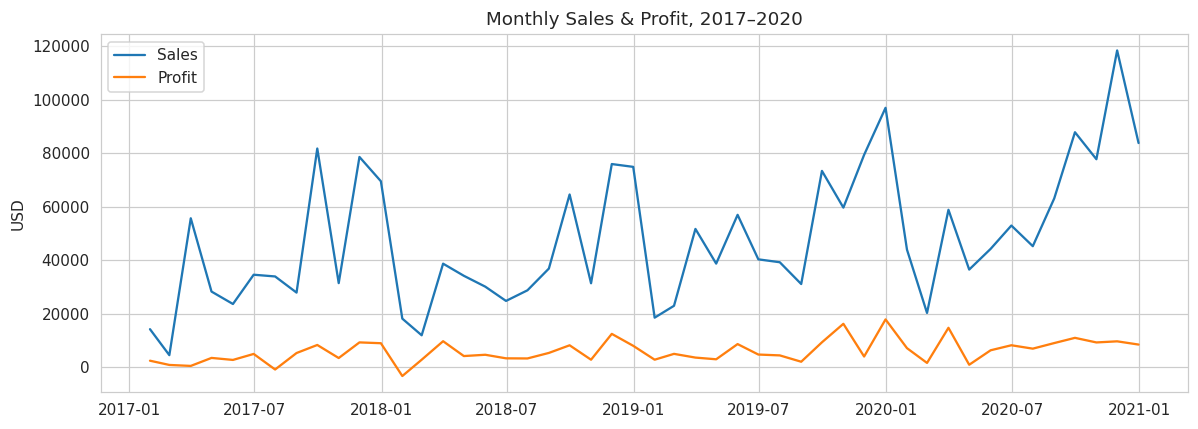

In [6]:
monthly = df.set_index('order_date').resample('ME')[['sales', 'profit']].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly['sales'], label='Sales')
ax.plot(monthly.index, monthly['profit'], label='Profit')
ax.set_title('Monthly Sales & Profit, 2017–2020')
ax.set_ylabel('USD')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Profit by category and subcategory

This is where the loss-making starts to show a pattern.

                       sales       profit    margin
category                                           
Technology       836154.0330  145454.9481  0.173957
Office Supplies  719047.0320  122490.8008  0.170352
Furniture        741999.7953   18451.2728  0.024867


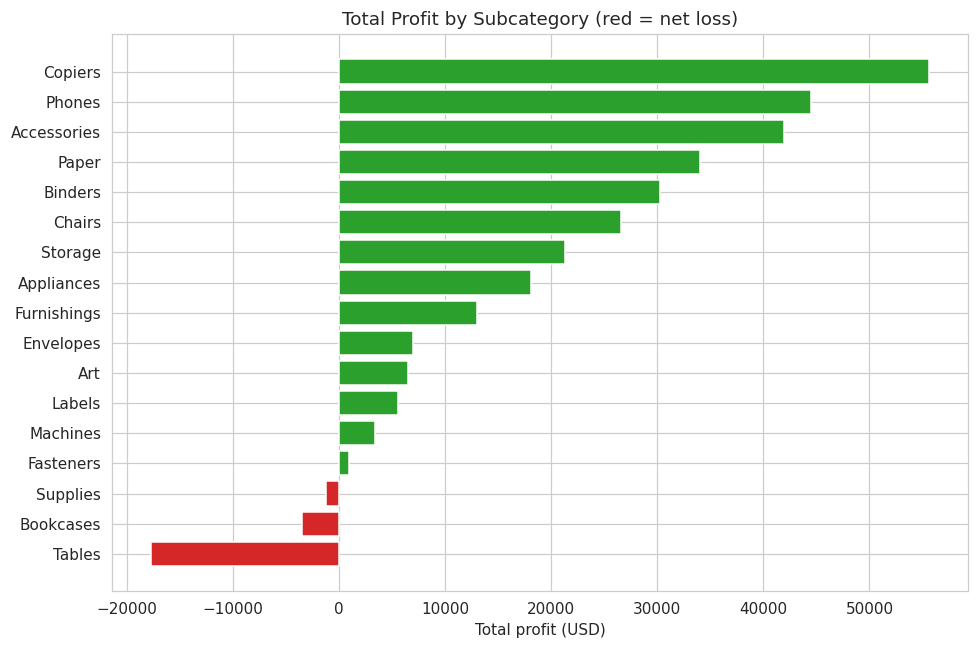

In [7]:
cat_profit = df.groupby('category')[['sales', 'profit']].sum()
cat_profit['margin'] = cat_profit['profit'] / cat_profit['sales']
print(cat_profit.sort_values('profit', ascending=False))

sub_profit = df.groupby('subcategory')['profit'].sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in sub_profit.values]
ax.barh(sub_profit.index, sub_profit.values, color=colors)
ax.set_title('Total Profit by Subcategory (red = net loss)')
ax.set_xlabel('Total profit (USD)')
plt.tight_layout()
plt.show()

**Tables** are the single biggest problem: they lose about \$17.7K overall, more than any other subcategory, with Bookcases and Supplies also net-negative. **Binders**, despite being net-profitable overall, has the *worst average margin* per transaction (around -20%) driven by a long tail of deeply-discounted sales — a pattern worth flagging separately from Tables.

## 6. The real driver: discount level

                    mean          sum  count
discount_bin                                
0%             66.900292  320987.6032   4798
1-10%          96.055074    9029.1770     94
11-20%         24.738824   91756.2975   3709
21-30%        -45.679636  -10369.2774    227
31-50%       -156.282991  -48447.7273    310
51%+          -89.438144  -76559.0513    856


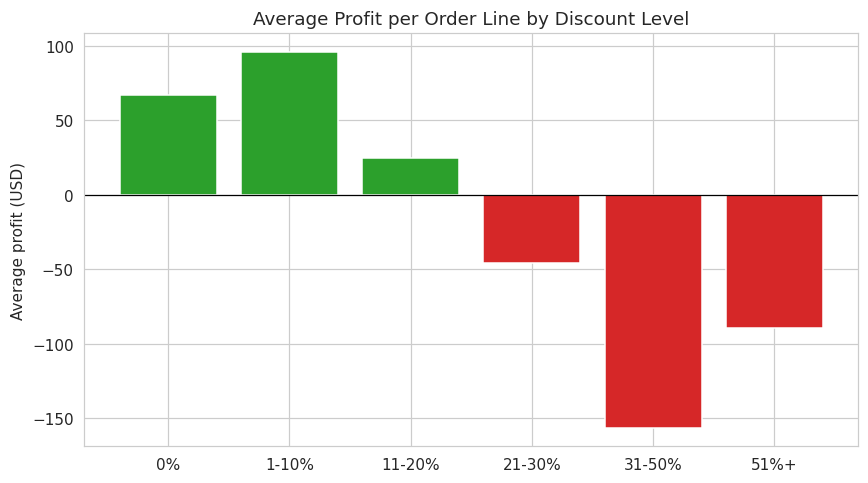

In [8]:
df['discount_bin'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
)

discount_summary = df.groupby('discount_bin', observed=True)['profit'].agg(['mean', 'sum', 'count'])
print(discount_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in discount_summary['mean']]
ax.bar(discount_summary.index.astype(str), discount_summary['mean'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit per Order Line by Discount Level')
ax.set_ylabel('Average profit (USD)')
plt.tight_layout()
plt.show()

In [9]:
mean_discount_loss = loss_rows['discount'].mean()
mean_discount_profit = df[df['profit'] > 0]['discount'].mean()
print(f'Average discount on loss-making lines:  {mean_discount_loss:.0%}')
print(f'Average discount on profit-making lines: {mean_discount_profit:.0%}')

Average discount on loss-making lines:  48%
Average discount on profit-making lines: 8%


This is the clearest signal in the dataset: **once discount exceeds ~20%, the average line item loses money**, and average profit gets worse the higher the discount climbs. Loss-making lines carry an average discount of ~48%, versus ~8% on profitable lines. Discounting, not cost or demand, looks like the main lever driving the loss-making tail.

## 7. Regional performance

               sales       profit    margin
region                                     
Central  501239.8908   39706.3625  0.079216
South    391721.9050   46749.4303  0.119343
East     678781.2400   91522.7800  0.134834
West     725457.8245  108418.4489  0.149448


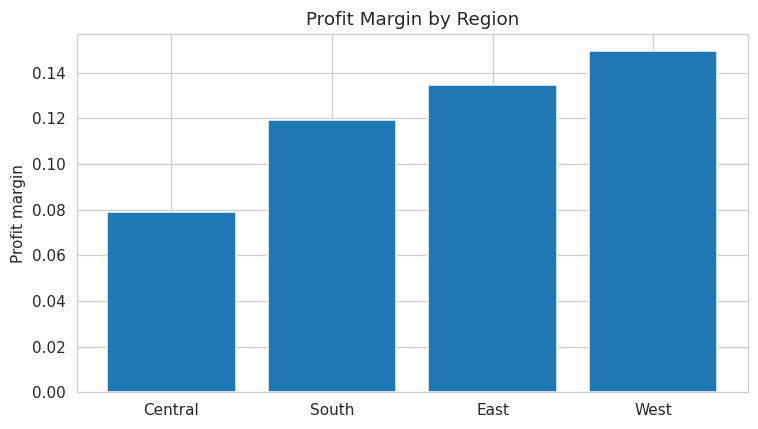

In [10]:
region_profit = df.groupby('region')[['sales', 'profit']].sum().sort_values('profit')
region_profit['margin'] = region_profit['profit'] / region_profit['sales']
print(region_profit)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(region_profit.index, region_profit['margin'], color='#1f77b4')
ax.set_title('Profit Margin by Region')
ax.set_ylabel('Profit margin')
plt.tight_layout()
plt.show()

**Central** region has the thinnest margin of the four, despite not being the smallest by sales — worth checking whether that's a discounting pattern specific to Central, or a product mix issue (more Tables/Bookcases sold there).

## 8. Putting it together: discount x subcategory

Is the discount effect concentrated in the subcategories that already lose money, or is it separate?

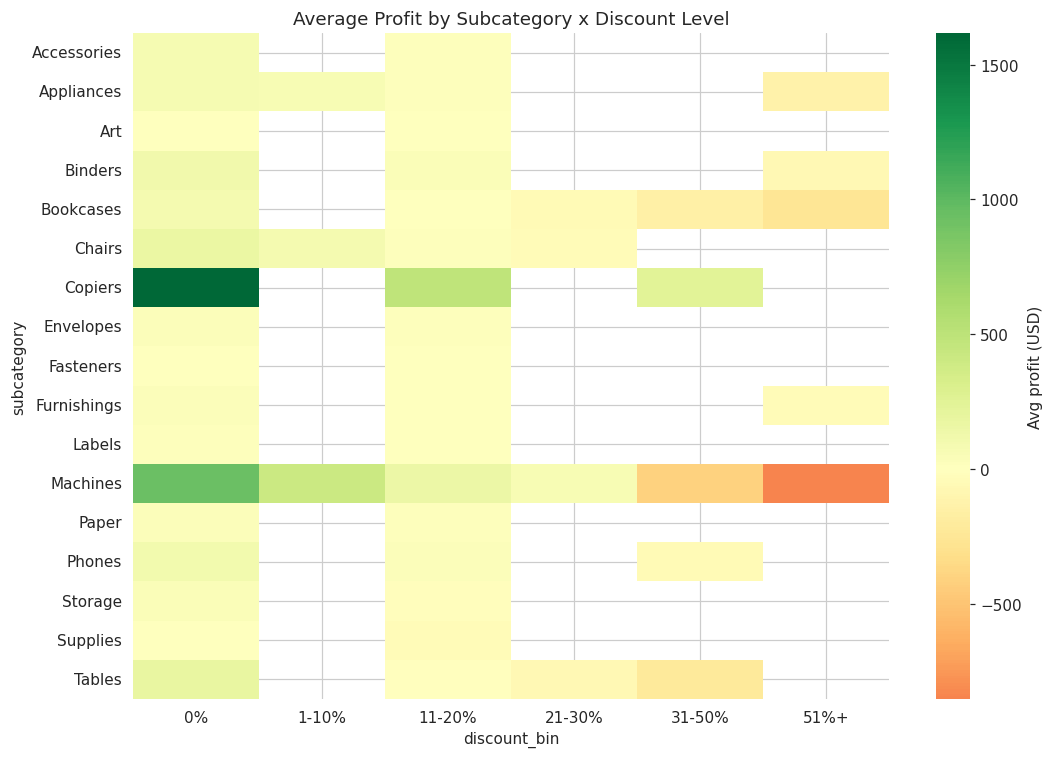

In [11]:
pivot = df.pivot_table(values='profit', index='subcategory', columns='discount_bin',
                        aggfunc='mean', observed=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, cmap='RdYlGn', center=0, annot=False, ax=ax, cbar_kws={'label': 'Avg profit (USD)'})
ax.set_title('Average Profit by Subcategory x Discount Level')
plt.tight_layout()
plt.show()

## 9. Recommendations

Based on the findings above:

1. **Cap discounts at 20% on Tables and Bookcases.** These subcategories are net loss-makers largely because deep discounts (30%+) are common on them; at discounts under 20% most subcategories stay profitable.
2. **Review Binders' pricing/promo policy separately.** It's net-profitable in total (high volume), but has the worst per-transaction margin — a high volume of small, deeply-discounted sales. Worth checking whether this is intentional loss-leader behavior or unmanaged discount creep.
3. **Investigate Central region's thin margin.** Check whether it's driven by product mix (more low-margin subcategories sold there) or a regional discounting habit, and align it toward West/East's approach.
4. **Set a discount approval threshold around 20-25%.** The data shows a clear inflection point: line items above this threshold average a negative profit; below it, they don't.
5. **Re-run this analysis quarterly** to confirm whether discount discipline actually improves subcategory-level margins over time.

## 10. Next steps

- Rebuild this same analysis in SQL to practice query-writing (window functions for running profit, CTEs for the discount-bin logic).
- Turn sections 4–8 into an interactive Tableau/Power BI dashboard with discount level and region as filters.
- Write a 1-page plain-English summary of the findings above for a non-technical stakeholder.